In [1]:
import os
from urllib.request import urlretrieve

BASE_URL = 'https://github.com/AllenDowney/ThinkDSP/raw/master/code/'


def download_if_needed(filename):
    """Скачивает файл из репозитория ThinkDSP, если его нет в текущей папке."""
    if not os.path.exists(filename):
        print(f'Downloading {filename}...')
        urlretrieve(BASE_URL + filename, filename)
    else:
        print(f'{filename} already exists')


for filename in [
    'thinkdsp.py',
    '180960__kleeb__gunshot.wav',
    '92002__jcveliz__violin-origional.wav',
    'stalbans_a_mono.wav',
    '170255__dublie__trumpet.wav',
]:
    download_if_needed(filename)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import Wave, read_wave, decorate

try:
    from scipy.signal import fftconvolve
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scipy'])
    from scipy.signal import fftconvolve


def copy_wave(wave):
    """Создает независимую копию Wave."""
    return Wave(np.copy(wave.ys), framerate=wave.framerate)


def next_power_of_two(n):
    """Ближайшая степень двойки, не меньшая n."""
    return 1 << (int(n) - 1).bit_length()


def zero_padded(wave, n):
    """Возвращает копию wave, дополненную нулями до длины n."""
    result = copy_wave(wave)
    result.zero_pad(n)
    return result


def make_linear_convolution_by_dft(wave, response):
    """Линейная свертка через ДПФ с предварительным дополнением нулями."""
    if wave.framerate != response.framerate:
        raise ValueError('У сигналов должна быть одинаковая частота дискретизации')

    n_linear = len(wave) + len(response) - 1
    n_fft = next_power_of_two(n_linear)

    wave_pad = zero_padded(wave, n_fft)
    response_pad = zero_padded(response, n_fft)

    spectrum = wave_pad.make_spectrum()
    transfer = response_pad.make_spectrum()

    output = (spectrum * transfer).make_wave()
    output.truncate(n_linear)
    output.normalize()
    return output


def make_linear_convolution_fast(wave, response):
    """Обычная линейная свертка, вычисленная эффективно через scipy.signal.fftconvolve."""
    ys = fftconvolve(wave.ys, response.ys, mode='full')
    output = Wave(ys, framerate=wave.framerate)
    output.normalize()
    return output

---

## Упражнение 10.1



### 10.1.1 Импульсная характеристика комнаты

В качестве импульсной характеристики используем запись выстрела. Начальную паузу обрезаем, затем оставляем `2**16` отсчетов, как в решении автора.


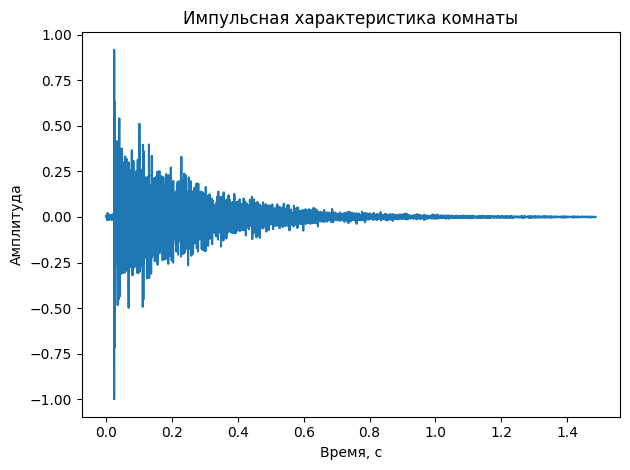

In [3]:
response = read_wave('180960__kleeb__gunshot.wav')

start = 0.12
response = response.segment(start=start)
response.shift(-start)
response.truncate(2**16)
response.normalize()

response.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Импульсная характеристика комнаты')

In [4]:
response.make_audio()

Передаточная функция — это ДПФ импульсной характеристики.


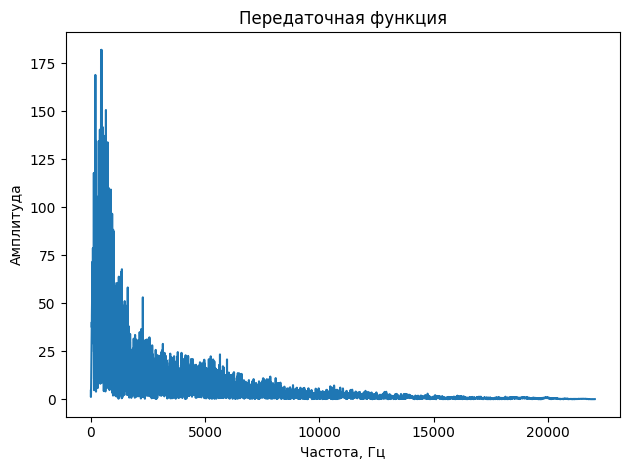

In [5]:
transfer = response.make_spectrum()
transfer.plot()
decorate(xlabel='Частота, Гц', ylabel='Амплитуда', title='Передаточная функция')

### 10.1.2 Входной сигнал: скрипка

Берем короткий фрагмент скрипки такой же длины, как импульсная характеристика.


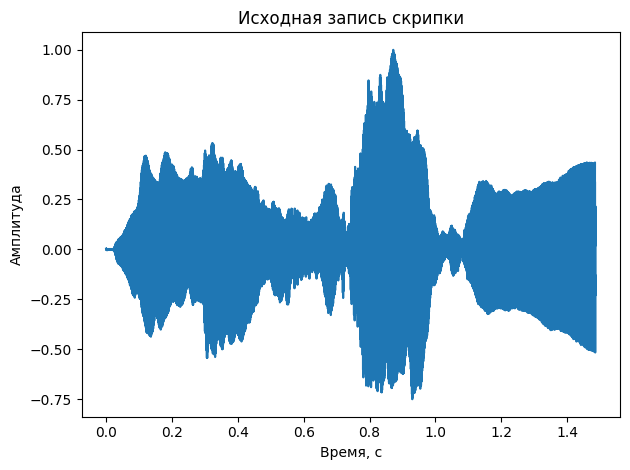

In [6]:
violin = read_wave('92002__jcveliz__violin-origional.wav')

start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)
violin.truncate(2**16)
violin.normalize()

assert violin.framerate == response.framerate

violin.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Исходная запись скрипки')

In [7]:
violin.make_audio()

### 10.1.3 Неправильный вариант: ДПФ без дополнения нулями

Здесь длины сигналов одинаковы, поэтому спектры можно перемножить напрямую. Но результат соответствует круговой свертке, а не линейной. Именно поэтому в начале может появляться лишний фрагмент, «завернутый» с конца.


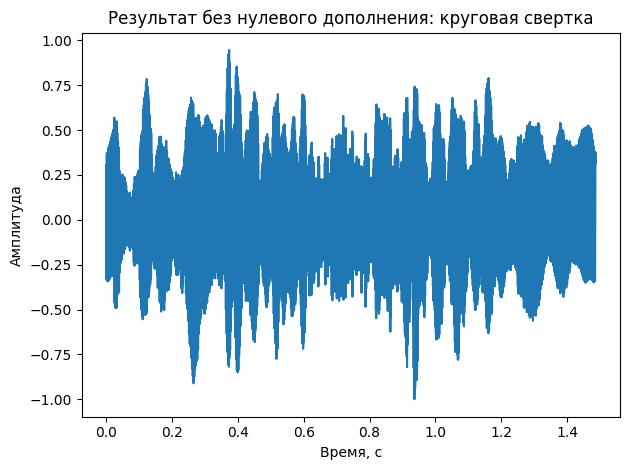

In [8]:
bad_output = (violin.make_spectrum() * response.make_spectrum()).make_wave()
bad_output.normalize()

bad_output.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Результат без нулевого дополнения: круговая свертка')

In [9]:
bad_output.make_audio()

Посмотрим отдельно начало сигнала: именно здесь обычно слышен эффект «заворота».


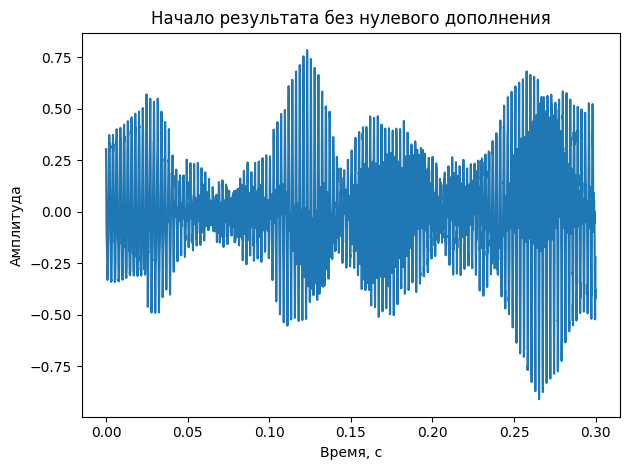

In [10]:
bad_start = bad_output.segment(start=0, duration=0.30)
bad_start.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Начало результата без нулевого дополнения')

### 10.1.4 Правильный вариант: нулевое дополнение перед ДПФ

Для линейной свертки двух сигналов длиной `N` и `M` нужна длина результата `N + M - 1`. Поэтому перед ДПФ дополняем оба сигнала нулями хотя бы до этой длины. Для эффективности берем ближайшую степень двойки.


In [11]:
n_linear = len(violin) + len(response) - 1
n_fft = next_power_of_two(n_linear)

n_linear, n_fft

(131071, 131072)

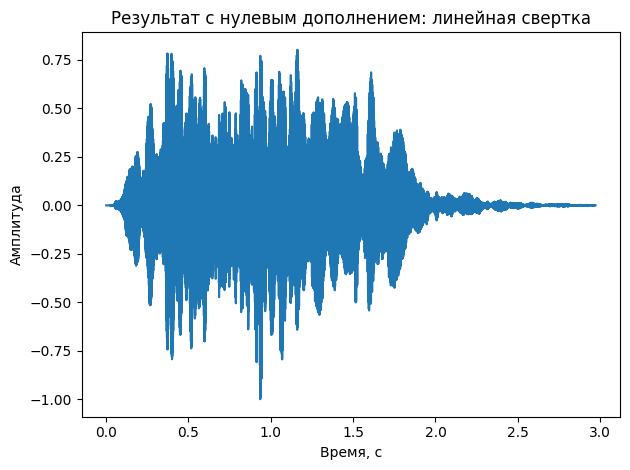

In [12]:
good_output = make_linear_convolution_by_dft(violin, response)

good_output.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Результат с нулевым дополнением: линейная свертка')

In [13]:
good_output.make_audio()

Сравним начало двух вариантов. У корректного результата в начале не должно быть лишней ноты, пришедшей с конца фрагмента.


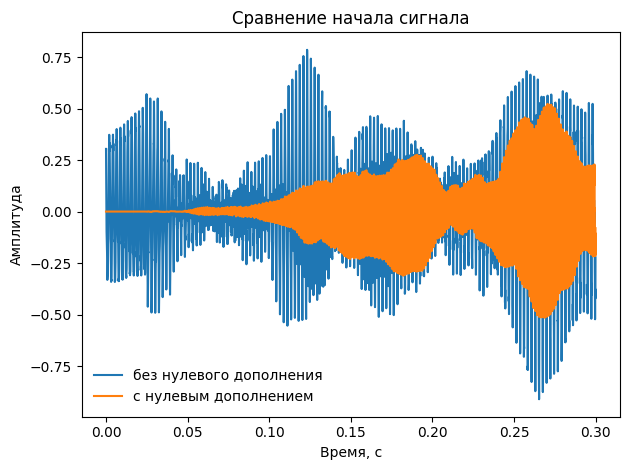

In [14]:
bad_output.segment(start=0, duration=0.30).plot(label='без нулевого дополнения')
good_output.segment(start=0, duration=0.30).plot(label='с нулевым дополнением')
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Сравнение начала сигнала')

### 10.1.5 Проверка через готовую функцию свертки

Ниже `fftconvolve` используется как быстрый способ вычислить обычную линейную свертку. Разница между этим результатом и ручным способом через ДПФ должна быть близка к машинной погрешности.


In [15]:
reference_output = make_linear_convolution_fast(violin, response)

# max_diff есть у объектов Wave из thinkdsp
max_difference = good_output.max_diff(reference_output)
max_difference

np.float64(0.0)

**Вывод по упражнению 10.1.** Умножение ДПФ без нулевого дополнения дает круговую свертку, поэтому часть конца сигнала может попасть в начало. Если перед вычислением ДПФ дополнить оба сигнала нулями до длины не меньше `N + M - 1`, получается линейная свертка, и лишняя нота в начале исчезает.


---

## Упражнение 10.2


### 10.2.1 Импульсная характеристика помещения


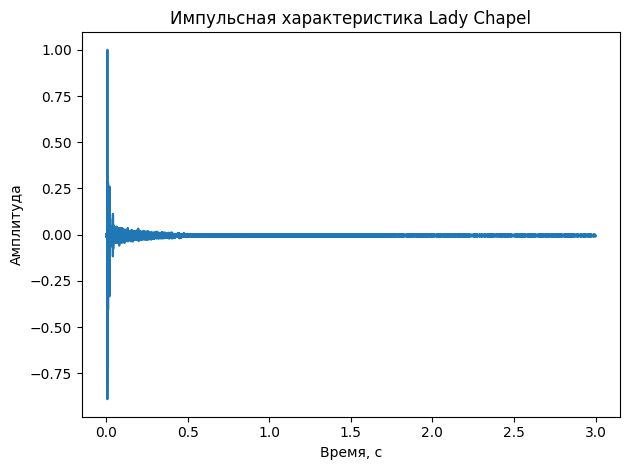

In [16]:
chapel_response = read_wave('stalbans_a_mono.wav')

# Первые 3 секунды достаточно хорошо показывают реверберацию,
# но не делают вычисления слишком тяжелыми.
chapel_response = chapel_response.segment(start=0, duration=3.0)
chapel_response.shift(0)
chapel_response.normalize()

chapel_response.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Импульсная характеристика Lady Chapel')

In [17]:
chapel_response.make_audio()

Передаточная функция помещения — это спектр импульсной характеристики.


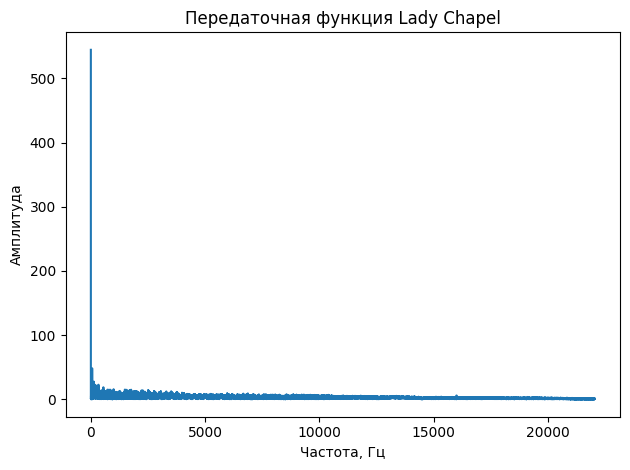

In [18]:
chapel_transfer = chapel_response.make_spectrum()
chapel_transfer.plot()
decorate(xlabel='Частота, Гц', ylabel='Амплитуда', title='Передаточная функция Lady Chapel')

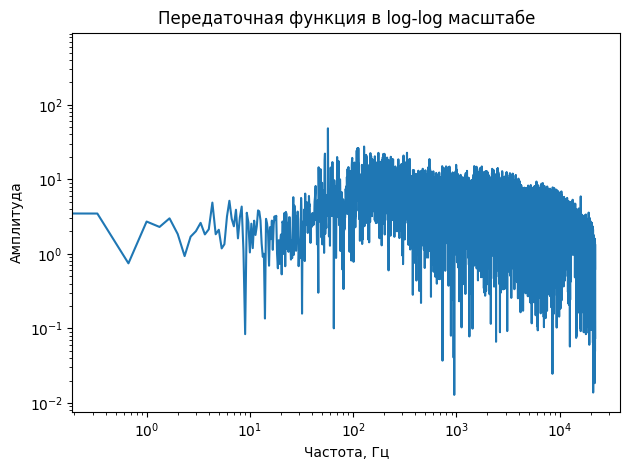

In [19]:
chapel_transfer.plot()
decorate(xlabel='Частота, Гц', ylabel='Амплитуда',
         xscale='log', yscale='log', title='Передаточная функция в log-log масштабе')

### 10.2.2 Короткая запись с той же частотой дискретизации

Используем запись трубы. Для удобства вычислений берем первые 1.5 секунды.


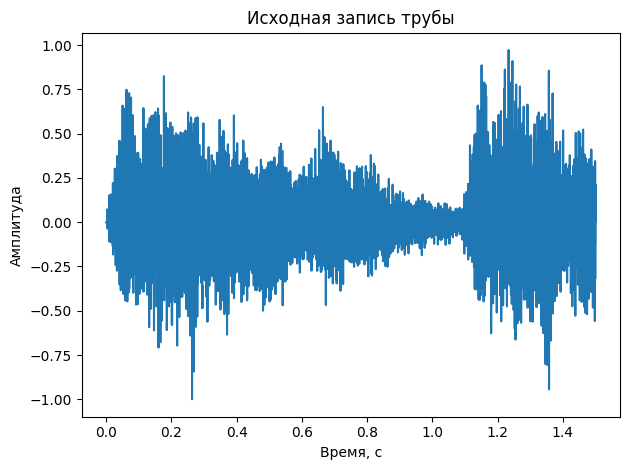

In [20]:
trumpet = read_wave('170255__dublie__trumpet.wav')
trumpet = trumpet.segment(start=0, duration=1.5)
trumpet.shift(0)
trumpet.normalize()

assert trumpet.framerate == chapel_response.framerate

trumpet.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Исходная запись трубы')

In [21]:
trumpet.make_audio()

### 10.2.3 Способ 1: свертка записи с импульсной характеристикой

Это прямая интерпретация ЛСС-модели: выход системы равен входному сигналу, свернутому с импульсной характеристикой.


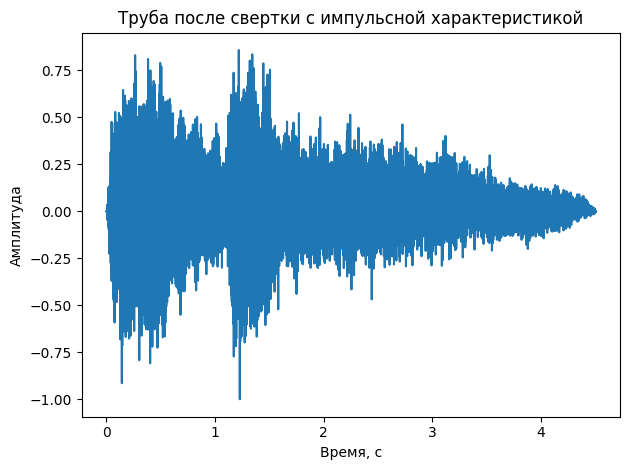

In [22]:
output_convolution = make_linear_convolution_fast(trumpet, chapel_response)

output_convolution.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Труба после свертки с импульсной характеристикой')

In [23]:
output_convolution.make_audio()

### 10.2.4 Способ 2: умножение ДПФ записи на фильтр

Теперь делаем то же самое через частотную область. Чтобы получить линейную, а не круговую свертку, снова используем нулевое дополнение.


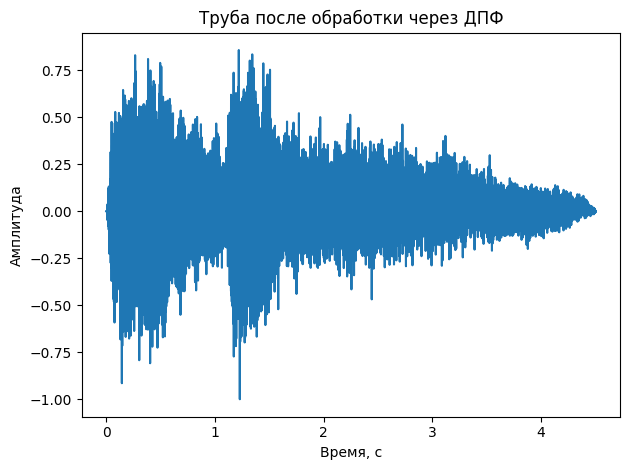

In [24]:
output_dft = make_linear_convolution_by_dft(trumpet, chapel_response)

output_dft.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Труба после обработки через ДПФ')

In [25]:
output_dft.make_audio()

### 10.2.5 Сравнение двух способов

Если оба способа реализованы корректно, результаты должны совпасть с точностью до численной погрешности.


In [26]:
output_convolution.max_diff(output_dft)

np.float64(5.551115123125783e-16)

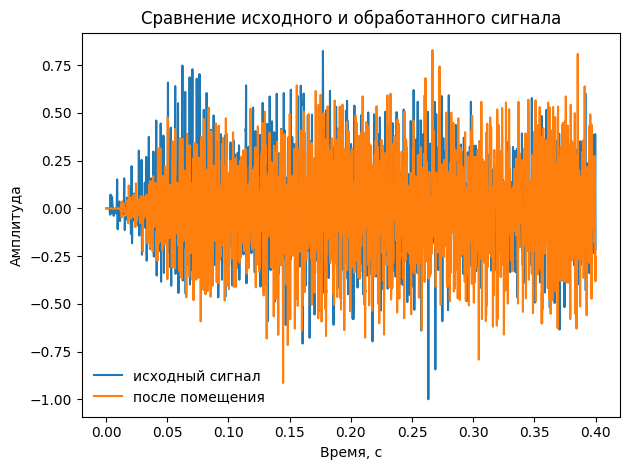

In [27]:
trumpet.segment(start=0, duration=0.40).plot(label='исходный сигнал')
output_dft.segment(start=0, duration=0.40).plot(label='после помещения')
decorate(xlabel='Время, с', ylabel='Амплитуда', title='Сравнение исходного и обработанного сигнала')